# **MÓDULO 21 - Projeto de Credit Score - Árvore de Decisão**


No módulo 17, vocês realizaram a primeira etapa do projeto de crédito de vocês. Então fizeram o tratamendo dos dados, balancearam as classes, transformaram as variáveis categóricas e separam base de treino e teste. Já no módulo 14, aplicaram a base já tratada o algoritmo de Naive Bayes, onde avaliaram os resultados das previsões. Nesse módulo aplicaremos a nossa base o algoritmo da árvore de decisão.

In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1) Comece carregando as bases de treino (X e y) e teste (X e y).
Verifique se o número de linhas condiz, se as variáveis estão corretas sendo apenas a de score para y e as demais nas bases de X e por último, se Y está balanceada no teste.

In [32]:
#seu código aqui
X_test = pd.read_csv("X_test.csv", delimiter=',')
X_train = pd.read_csv("X_train_balanced.csv", delimiter=',')
y_test = pd.read_csv("y_test.csv", delimiter=',')
y_train = pd.read_csv("y_train_balanced.csv", delimiter=',')

In [33]:
print("Tamanho de X_train:", X_train.shape)

Tamanho de X_train: (252, 10)


In [34]:
print("Tamanho de X_test:", X_test.shape)

Tamanho de X_test: (41, 10)


In [35]:
print("Tamanho de y_train:", y_train.shape)

Tamanho de y_train: (252, 1)


In [36]:
print("Tamanho de y_test:", y_test.shape)

Tamanho de y_test: (41, 1)


In [37]:
y_test

,Credit_Score_encoded
0,0
1,1
2,0
3,1
4,1
5,0
6,1
7,1
8,1
9,1


In [38]:
X_test

,Age,Income,Number of Children,education_ordinal,Gender_Female,Gender_Male,Marital Status_Married,Marital Status_Single,Home Ownership_Owned,Home Ownership_Rented
0,25,55000.0,0,3,True,False,False,True,False,True
1,48,87500.0,1,5,True,False,True,False,True,False
2,26,55000.0,1,3,True,False,True,False,True,False
3,39,62500.0,2,3,True,False,True,False,True,False
4,35,90000.0,1,5,True,False,True,False,True,False
5,25,55000.0,0,3,True,False,False,True,False,True
6,48,82500.0,1,5,True,False,True,False,True,False
7,48,82500.0,1,5,True,False,True,False,True,False
8,36,95000.0,2,4,True,False,True,False,True,False
9,29,95000.0,1,1,True,False,True,False,True,False


In [39]:
y_train

,Credit_Score_encoded
0,0
1,2
2,0
3,0
4,0
...,...
247,2
248,2
249,2
250,2


In [40]:
X_train

,Age,Income,Number of Children,education_ordinal,Gender_Female,Gender_Male,Marital Status_Married,Marital Status_Single,Home Ownership_Owned,Home Ownership_Rented
0,26,45000.000000,0,2,True,False,False,True,False,True
1,29,27500.000000,0,1,True,False,False,True,False,True
2,25,62500.000000,0,3,True,False,False,True,False,True
3,29,68000.000000,2,5,True,False,True,False,True,False
4,31,65000.000000,0,3,False,True,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...
247,27,36803.652916,0,1,True,False,False,True,False,True
248,27,37500.000000,0,1,True,False,False,True,False,True
249,28,29946.263487,0,1,True,False,False,True,False,True
250,27,35412.944984,0,1,True,False,False,True,False,True


In [41]:
# Contar o número de exemplos de cada classe em y_train
train_balance = y_train.value_counts()
print("Balanceamento em y_train:")
print(train_balance)

# Contar o número de exemplos de cada classe em y_test
test_balance = y_test.value_counts()
print("\nBalanceamento em y_test:")
print(test_balance)

Balanceamento em y_train:
Credit_Score_encoded
0                       84
1                       84
2                       84
Name: count, dtype: int64

Balanceamento em y_test:
Credit_Score_encoded
1                       29
0                        6
2                        6
Name: count, dtype: int64


# 2) Explique com suas palavras, qual o passo a passo para a aplicação do algoritmo da árvore de decisão, não esqueça de citar a etapa de avaliação do modelo e também como podemos melhorar nosso modelo.

#### Depois do pré processamento dos dados, devemos criar o algoritmo de treino, definindo o criterion como sendo o indice de gini e colocamos o random_state para garantir a reprodutibilidade dos dados. É possível visualizar todos os parametros usando o get_params. Usamos o fit com os dados de treino e os resultados. 

#### Depois de criar o algoritmo, usamos a base de treino com o parametro predict e visualizamos os resultados do treinamento. Primeiro temos a acuracia e depois podemos gerar um relatorio de classificação que tem a precisão de cada predict, o recall e o f1. A precisão mede a proporção de verdadeiros positivos corretamente previstos em todas as amostras previstas como positivo. O Recall Mede a proporção de verdadeiros positivos corretamente previtos em relação a todas as amostras que realmente são positivas e o F1 combina a precisão com o recall em uma única medida. Depois podemos gerar a matriz de confusão para uma imagem gráfica dos valores previstos e dos reais e quantos erraram ou acertaram.

#### Em seguida agente passa ao algoritmo os dados de teste e gera todos os dados de validação acima novamente. Poderemos comparar os resultados e identificar se ele está prevendo bem ou se teremos que ajustar. Temos várias formas de ajustar caso possamos ver que as previsões na base de teste não está boa. Podemos começar a importância das características, geramos um gráfico que mostra o nivel de importancia que cada característica tem com o target. Assim poderemos treinar o algoritmo somente com as features mais importantes e novamente analisar os resultados. Temos outros parâmetros que podemos usar caso o treinamento ainda não fique bom, inclusive reduzindo o nivel de profundidade da árvore, até alcançarmos um bom resultado.

# 3) Aplique o algortimo da árvore de decisão aos dados de treinamento, utilizando critério de Gini e random state = 0.
Traga a acurácia para o modedlo com os dados de treino.

In [43]:
#seu código aqui
arvore_churn = DecisionTreeClassifier (criterion = 'gini', random_state = 0)
arvore_churn.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [45]:
previsoes = arvore_churn.predict(X_train)
acuracia = accuracy_score(y_train, previsoes)
print("Acurácia:", acuracia)

Acurácia: 1.0


In [47]:
relatorio = classification_report(y_train, previsoes)
print("Relatório de Classificação:")
print(relatorio)

Relatório de Classificação:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        84
           1       1.00      1.00      1.00        84
           2       1.00      1.00      1.00        84

    accuracy                           1.00       252
   macro avg       1.00      1.00      1.00       252
weighted avg       1.00      1.00      1.00       252



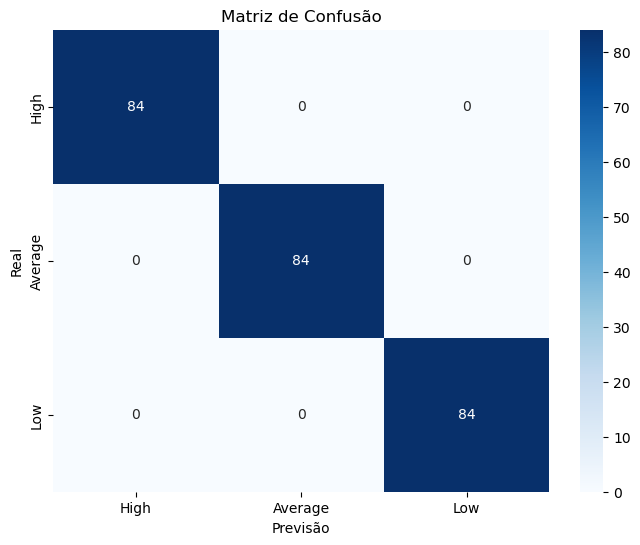

In [48]:
matriz_confusao = confusion_matrix(y_train, previsoes)

# Plotando a matriz de confusão como um mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_confusao, annot=True, cmap='Blues', fmt='d',
            xticklabels=['High', 'Average', 'Low'],
            yticklabels=['High', 'Average', 'Low'])
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

# 4) Aplique o modelo aos dados de teste e realize a avaliação dos resultados. Não se esqueça de avaliar com as suas palavras e comparar o desempenho da base treino com a teste.

In [49]:
#seu código aqui
y_arvore_test = arvore_churn.predict(X_test)

In [50]:
acuracia = accuracy_score(y_test, y_arvore_test)
print("Acurácia:", acuracia)

Acurácia: 0.926829268292683


In [51]:
relatorio_test = classification_report(y_test, y_arvore_test)
print("Relatório de Classificação:")
print(relatorio_test)

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.71      0.83      0.77         6
           1       0.96      0.93      0.95        29
           2       1.00      1.00      1.00         6

    accuracy                           0.93        41
   macro avg       0.89      0.92      0.91        41
weighted avg       0.93      0.93      0.93        41



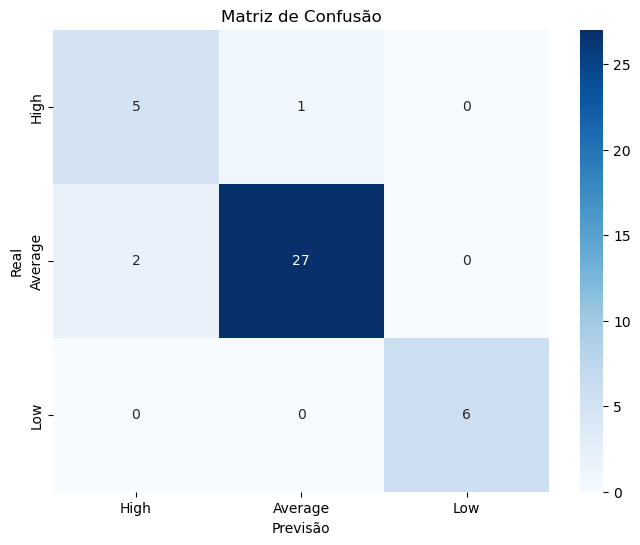

In [53]:
matriz_confusao_test = confusion_matrix(y_test, y_arvore_test)

# Plotando a matriz de confusão como um mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_confusao_test, annot=True, cmap='Blues', fmt='d',
            xticklabels=['High', 'Average', 'Low'],
            yticklabels=['High', 'Average', 'Low'])
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

# 5) Plote a árvore de decisão.
É possível fazer uma avaliação visual? Qual a profundidade da árvore?

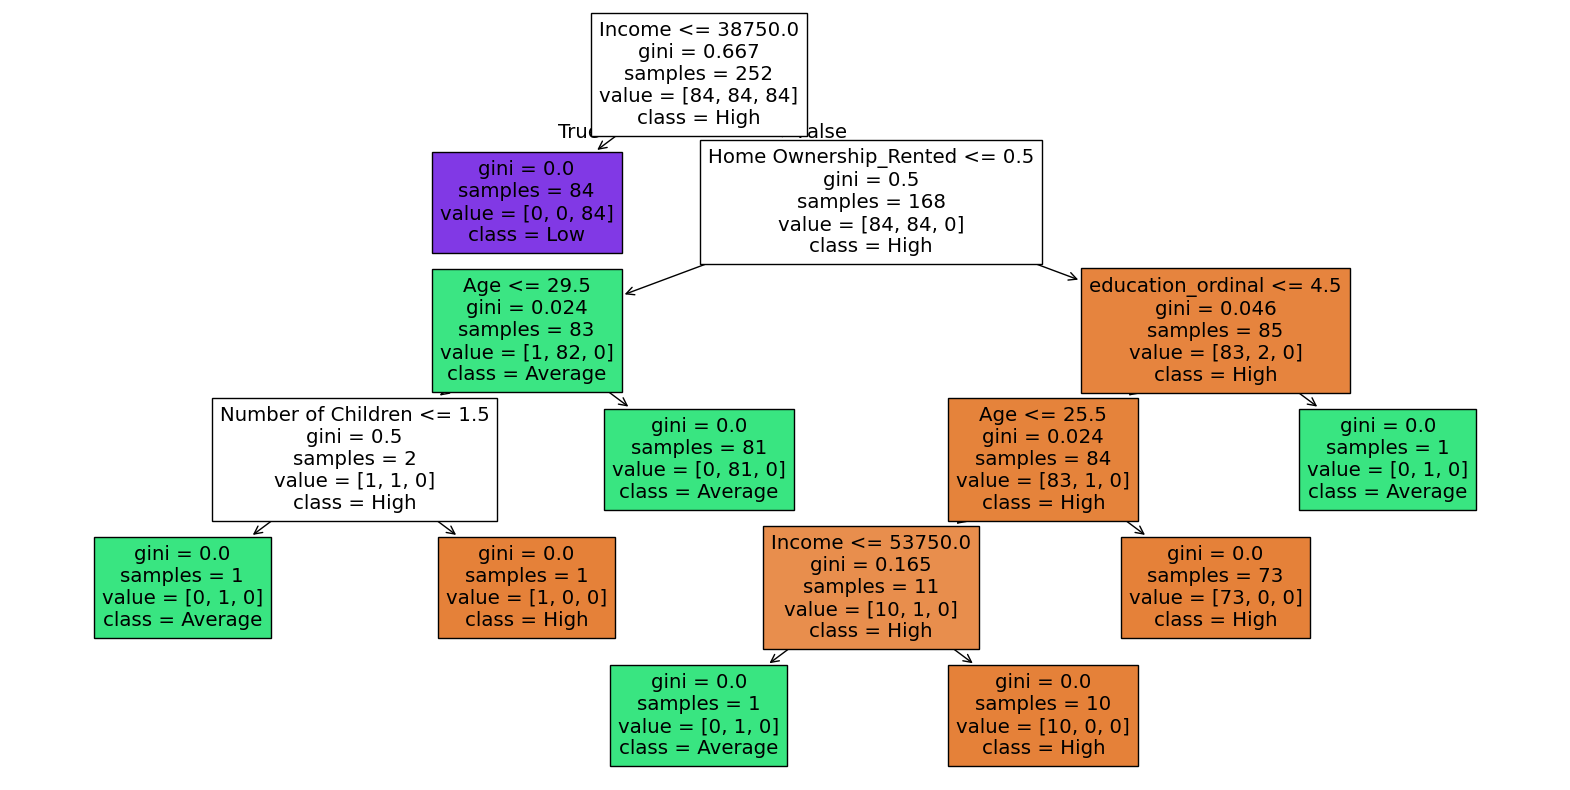

In [57]:
#seu código aqui
plt.figure(figsize=(20,10))
plot_tree(arvore_churn, filled=True, feature_names=X_test.columns, class_names=['High', 'Average', 'Low'])
plt.show()

# 6) Identifique as 2 principais features do modelo.


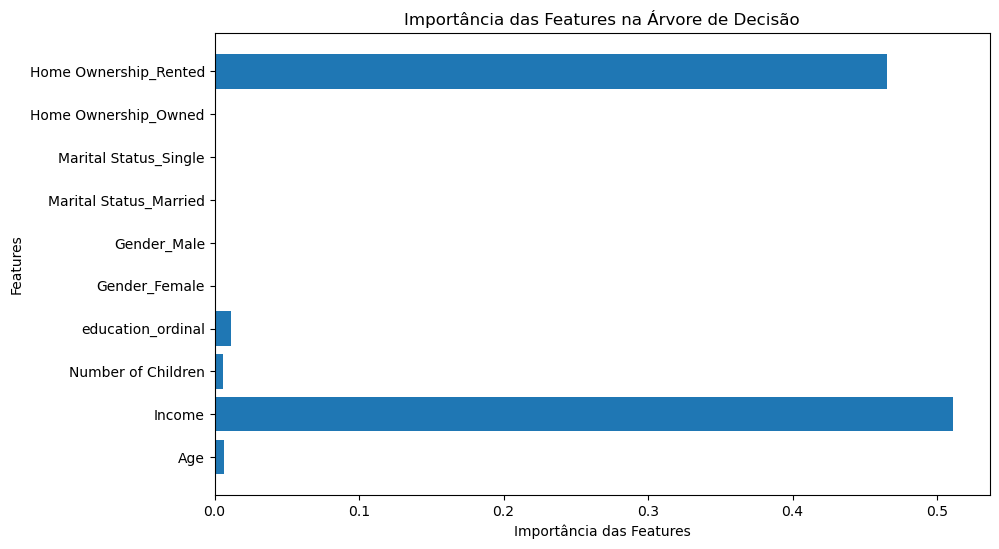

In [58]:
#seu código aqui
# Obtendo a importância das características do modelo de árvore de decisão
importancias_features = arvore_churn.feature_importances_

# Obtendo os nomes das características
nomes_features = X_train.columns

# Criando um gráfico de barras para visualizar a importância das características
plt.figure(figsize=(10, 6))
plt.barh(nomes_features, importancias_features)
plt.xlabel('Importância das Features')
plt.ylabel('Features')
plt.title('Importância das Features na Árvore de Decisão')
plt.show()

#### As features mais importântes são: Income e Home Ownership_Rented

# 7) Rode um modelo de árvore de decisão apenas com as 2 principais features encontradas. E avalie os resultados. Para você o desempenho da árvore está melhor que o modelo anterior? Justifique.

In [60]:
#seu código aqui
X_train_reduzido = X_train[['Income', 'Home Ownership_Rented']]
X_test_reduzido = X_test[['Income', 'Home Ownership_Rented']]

In [61]:
arvore_churn_reduzido = DecisionTreeClassifier (criterion = 'gini', random_state = 0)
arvore_churn_reduzido.fit(X_train_reduzido, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [62]:
previsoes_reduzido = arvore_churn_reduzido.predict(X_test_reduzido)

In [66]:
acuracia = accuracy_score(y_test, previsoes_reduzido)
print("Acurácia:", acuracia)

Acurácia: 0.9512195121951219


In [63]:
relatorio = classification_report(y_test, previsoes_reduzido)
print("Relatório de Classificação:")
print(relatorio)

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.83      0.83      0.83         6
           1       0.97      0.97      0.97        29
           2       1.00      1.00      1.00         6

    accuracy                           0.95        41
   macro avg       0.93      0.93      0.93        41
weighted avg       0.95      0.95      0.95        41



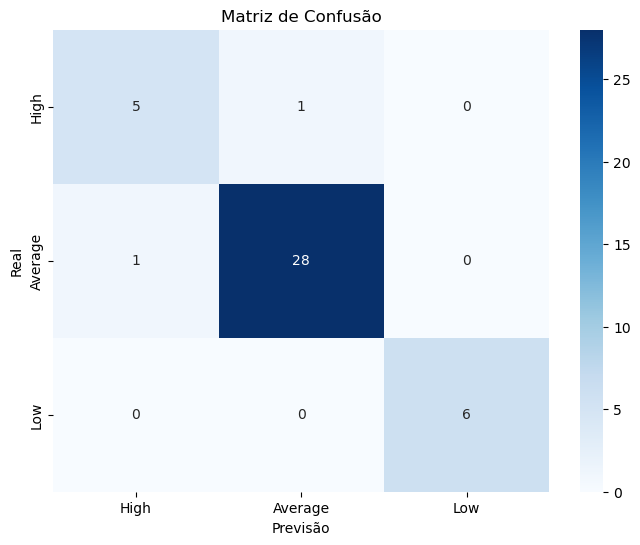

In [64]:
matriz_confusao = confusion_matrix(y_test, previsoes_reduzido)

# Plotando a matriz de confusão como um mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_confusao, annot=True, cmap='Blues', fmt='d',
            xticklabels=['High', 'Average', 'Low'],
            yticklabels=['High', 'Average', 'Low'])
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

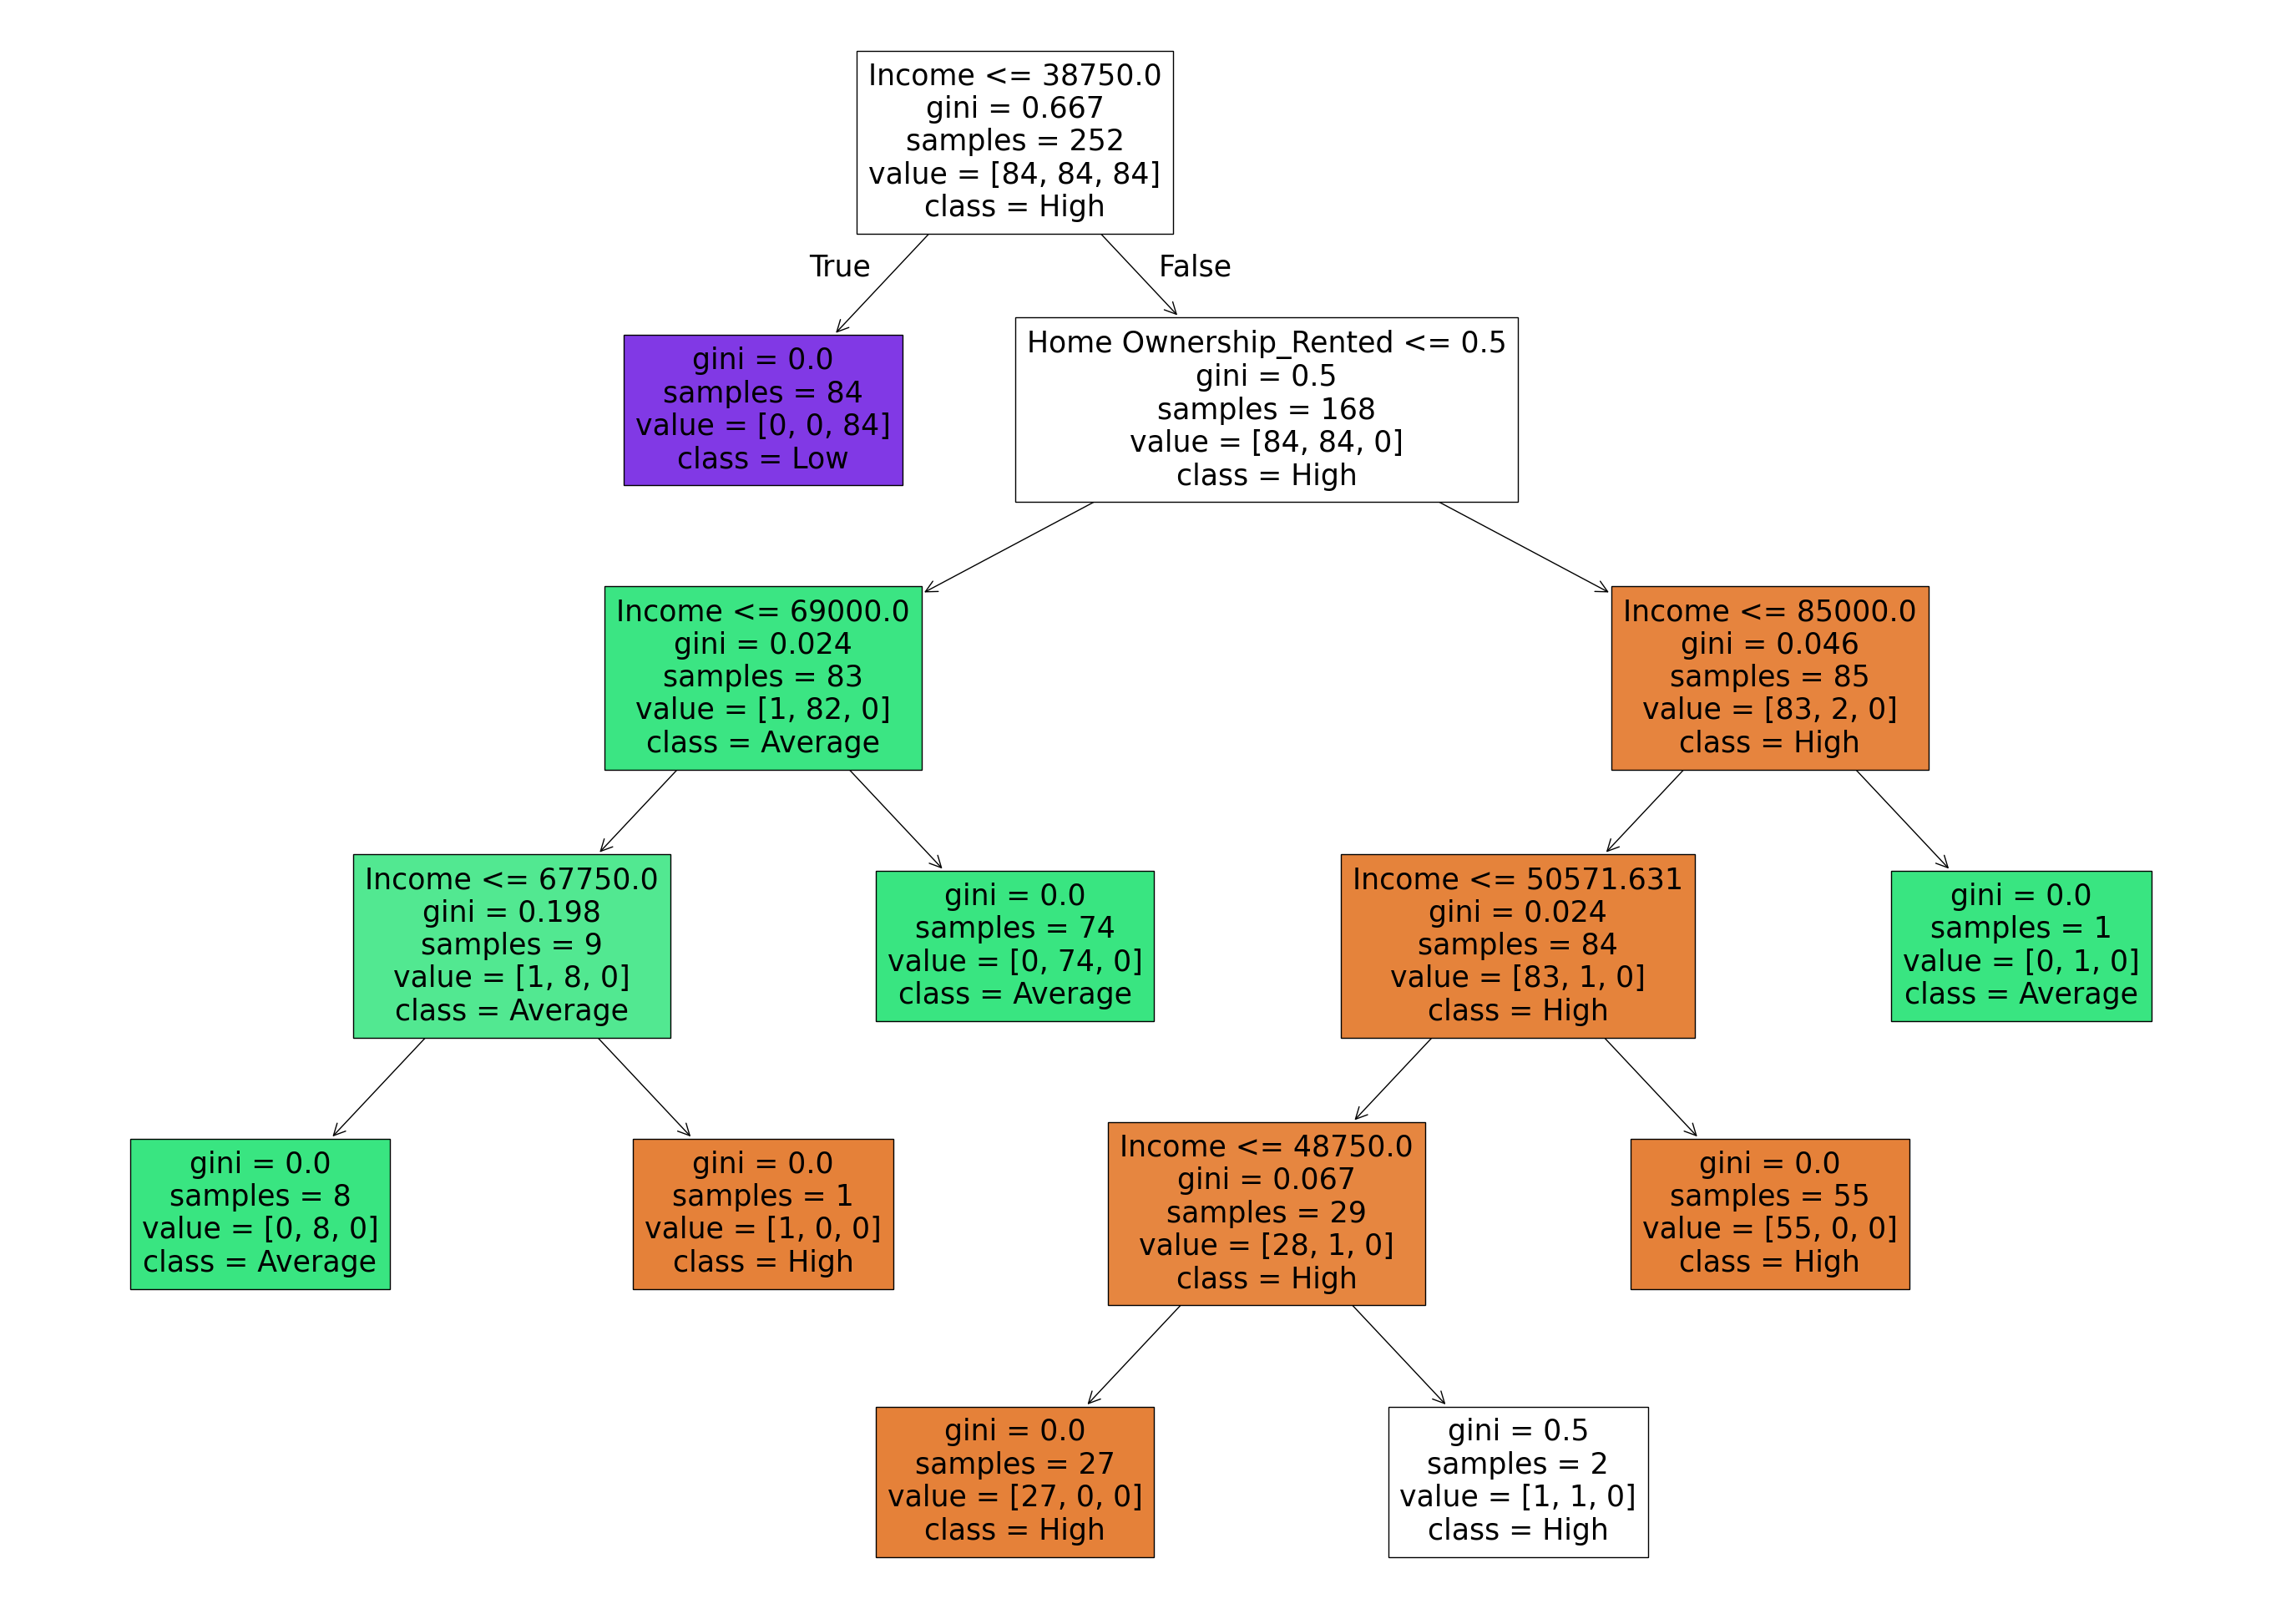

In [65]:
plt.figure(figsize=(35,25))
plot_tree(arvore_churn_reduzido, filled=True, feature_names=X_train_reduzido.columns, class_names=['High', 'Average', 'Low'])
plt.show()

# 8) Compare os resultados obtidos com a árvore de decisão com os resultados do Naive Bayes (Exercício módulo 20). Qual parece ter se adequado melhor aos dados e tem melhores resultados de avaliação? Justifique.

#### O algoritmo de naive bayes teve uma acuracia de 100% nos dados de teste enquanto que a árvore teve de 95%. Inclusive a matriz de confusão não mostrou nenhuma predição errada no primeiro, enquanto que na árvore pudemos ver alguns erros. No entanto como naive bayes não leva em conta as relações que as variáveis possuem, acredito que a árvore tenha um resultado mais próximo da realidade. O ideal seria treinar os modelos com uma base maior afim de confirmar o comportamento, principalmente de bayes, e assim termos uma resposta mais correta. Mas levando em conta a forte relação de income e home ownership_rented com o target e que o resultado de 100% de naive bayes é muito raro e dificil de ocorrer, acredito que o algoritmo da árvore se adequa melhor aos dados do que o algoritmo de Bayes. 